# 3D balanced SSFP (bSSFP)

**Balanced SSFP** is a gradient-echo family defined by a condition on its gradients: over one
repetition -- from one RF pulse to the next -- the net gradient area on **every** axis returns to
zero. Each repetition excites, encodes one line of k-space, reads it out, and unwinds all of its
encoding again, leaving nothing behind on any axis.

That condition is what the sequence is named for, and it is all a single repetition can promise.
Run many of them at a short, constant TR and the transverse magnetisation surviving each pulse can
stay coherent from one repetition to the next instead of being spoiled away, which is what allows a
bSSFP train to settle into its characteristic high-signal steady state. **Whether it actually
does** depends on T1, T2, the flip angle, the RF phase schedule and the off-resonance distribution
-- none of which a single repetition knows anything about. Balance removes the net gradient
dephasing of stationary spins; it does not by itself keep everything in phase.

bSSFP is used where signal per unit time matters: cardiac cine, fetal imaging, fast abdominal work.
Its price is a sensitivity to off-resonance that appears as dark **banding** wherever the field
drifts far enough across a repetition.

This notebook builds the **3D** version, where a second phase-encode axis divides a slab into
partitions. The 2D sequence gives `z` one job -- select a slice and undo that selection. In 3D the
same axis has to do three: select the slab, balance that selection, **and** encode `kz`. How those
three share one axis is the question here, and the answer turns out to be about *ownership*
between neighbouring repetitions rather than about arithmetic.

In [1]:
from pathlib import Path

import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=32, grad_unit='mT/m',
    max_slew=130, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

# The acquisition this notebook is about.  Dimensions follow the 3D bSSFP protocols in the
# segmented-SSFP literature (Spincemaille et al. 2004 image a 256 x 256 x 16 volume over a 30 cm
# FOV at TR 4.1 ms); 192 x 192 x 16 over the same FOV lands on essentially the same TR here.
FOV_MM = (300.0, 300.0, 96.0)       # encoded x, y, z field of view
MATRIX = (192, 192, 16)             # readout samples, phase-encode lines, partitions
SLAB_MM = 80.0                      # the excited slab
FLIP_DEG = 45.0
BANDWIDTH_HZ_PX = 700.0             # wide, because a short TR is the whole point
RF_DURATION_S = 0.8e-3

NX, NY, NZ = MATRIX
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)

print(f'{NX} x {NY} x {NZ} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} x {FOV_MM[2]:.0f} mm')
print(f'voxel {FOV_MM[0] / NX:.2f} x {FOV_MM[1] / NY:.2f} x {FOV_MM[2] / NZ:.2f} mm')
print(f'excited slab {SLAB_MM:.0f} mm inside an encoded z extent of {FOV_MM[2]:.0f} mm')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


192 x 192 x 16 over 300 x 300 x 96 mm
voxel 1.56 x 1.56 x 6.00 mm
excited slab 80 mm inside an encoded z extent of 96 mm


### Two different z numbers

`SLAB_MM` and `FOV_MM[2]` are independent, and here they deliberately differ. The slab thickness is
an RF and gradient property: how much of the patient the pulse excites. The encoded z extent is a
k-space sampling property: the partition step is `1/FOV_z`, and that step sets how wide a region
the reconstruction can place signal into before it wraps.

Encoding a wider extent than is excited is the z equivalent of oversampling. A slab profile has
transition regions at its edges rather than a sharp cut-off, so excited signal reaches somewhat
beyond the nominal slab; if the encoded extent matched the nominal slab, that signal would sit
outside the unambiguous region and alias back across it. Giving the encoding more room than the
excitation keeps the excited signal inside the region the partitions can resolve.

## One repetition

`sc.modules.bSSFP3DTR` is the repeating unit: one excitation, one encoded readout, and the
gradient lobes that return every axis to zero. It is **not** a scan — it does not know how many
repetitions there are, what order they run in, or how the steady state is established. Those
belong to whatever writes the loop, and the last section comes back to why.

In [2]:
tr = sc.modules.bSSFP3DTR(
    opts=opts,
    fov_mm=FOV_MM,
    matrix=MATRIX,
    slab_thickness_mm=SLAB_MM,
    flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX,
    rf_duration_s=RF_DURATION_S,
)

print(f'TE               {tr.te_s * 1e3:7.3f} ms')
print(f'TR               {tr.tr_s * 1e3:7.3f} ms')
print(f'TE / TR          {tr.te_s / tr.tr_s:7.4f}')
print(f'centre of k      line {tr.center_line}, partition {tr.center_partition}')
print(f'dkz              {tr.dk_per_m("z"):7.3f} 1/m')
print(f'symmetry residual{tr.symmetry_residual_s * 1e6:7.3f} us '
      f'(raster is {float(opts.grad_raster_time) * 1e6:.0f} us)')

TE                 2.104 ms
TR                 4.210 ms
TE / TR           0.4998
centre of k      line 96, partition 8
dkz               10.417 1/m
symmetry residual -0.900 us (raster is 10 us)


### TE = TR/2 is the realisation, not the definition

Three things are worth keeping apart, because a notebook that collapses them teaches the wrong
causality:

```text
the balance definition        net gradient area zero on every axis, RF centre to RF centre
the default realisation       TE = TR/2, the symmetric placement of the echo in that interval
the steady-state contrast     a property of the repeated train: tissue relaxation, the flip
                              angle, the RF phase schedule and the off-resonance response
```

Balance says nothing about where the echo falls; an asymmetric echo is still balanced, and this
module will build one when asked. Putting the echo at the midpoint is the conventional symmetric
realisation and is the default here. It is not what *creates* bSSFP's contrast -- that belongs to
the train, not to a single repetition's echo placement.

`symmetry_residual_s` above is how far the echo sits from the exact midpoint. It is not zero
because the midpoint need not land on the gradient raster, and the module reports what it achieved
rather than rounding the TE it declares.

## The timing origin is the RF effective centre

Every time this module declares is measured from the **effective centre** of the RF pulse, read
from the waveform rather than taken as the midpoint of the event:

```text
TE               = echo - RF effective centre of repetition n
TR               = RF effective centre of n+1 - RF effective centre of n
balance interval = [RF effective centre of n, RF effective centre of n+1]
```

For a symmetric pulse the effective centre is near the middle; for a minimum-phase pulse it is
nowhere near it, and a caller who derived the origin from a pulse duration would be declaring a TE
it does not achieve. `time_to_rf_center()` reports where it lands inside the block so nothing
downstream has to reconstruct it.

In [3]:
print(f'block starts at              0.000 ms')
print(f'RF effective centre at   {tr.time_to_rf_center() * 1e3:9.3f} ms')
print(f'echo at                  {tr.time_to_echo() * 1e3:9.3f} ms')
print(f'block ends at            {tr.build(line=0, partition=0).duration * 1e3:9.3f} ms')
print()
print(f'echo - RF centre         {(tr.time_to_echo() - tr.time_to_rf_center()) * 1e3:9.3f} ms'
      f'   = TE ({tr.te_s * 1e3:.3f} ms)')

block starts at              0.000 ms
RF effective centre at       0.800 ms
echo at                      2.904 ms
block ends at                4.210 ms

echo - RF centre             2.104 ms   = TE (2.104 ms)


## The z axis does three jobs

The slab-selection gradient is playing while the RF is on, so part of its area falls **before** the
RF effective centre and part **after** it. Call those `A_pre` and `A_post`. The module measures
both from the waveform rather than assuming they are equal: for a symmetric pulse they nearly are,
but for a minimum-phase pulse the effective centre is nowhere near the waveform's midpoint, and
assuming equality there would mis-state the interval the balance condition is about.

Over one RF-to-RF interval the z axis therefore sees contributions from **two** repetitions, plus
whatever encodes the partition. This module plays three z lobes per repetition:

```text
lead(n)   = -A_pre(n)             before the pulse    -- cancels this pulse's leading portion
tail(n)   = -A_post(n) + K(p)     after the pulse     -- cancels its trailing portion AND encodes kz
rewind(n) = -K(p)                 after the echo      -- unwinds this repetition's own encoding
```

`K(p)` is the k-space position partition `p` encodes, which is `pe_z.k_per_m(p)`. The encode is
**lumped into** the balancing lobe rather than played beside it: the z axis is already busy between
the pulse and the echo, and a second gradient there would merge with the first into a waveform that
exceeds the slew limit at the edge of the partition table. One lobe carrying the signed sum is the
same moment in a legal shape.

The rest of this notebook does not inspect those lobes directly. It measures what they produce --
the net area over the interval, and the k-space position at the echo -- which is the thing the
contract is actually about.

In [4]:
print(f'{"partition":>10}{"K(p), 1/m":>12}{"":>4}{"of the table":>14}')
for p in (0, 1, tr.center_partition, NZ - 2, NZ - 1):
    k = tr.pe_z.k_per_m(p)
    marker = '  <- centre, encodes nothing' if p == tr.center_partition else ''
    print(f'{p:>10}{k:>12.2f}{"":>4}{k / tr.dk_per_m("z"):>+10.0f} dkz{marker}')
print()
print(f'dkz = {tr.dk_per_m("z"):.3f} 1/m, so the table spans '
      f'{tr.pe_z.k_per_m(0):.1f} .. {tr.pe_z.k_per_m(NZ - 1):+.1f} 1/m')

 partition   K(p), 1/m      of the table
         0      -83.33            -8 dkz
         1      -72.92            -7 dkz
         8        0.00            +0 dkz  <- centre, encodes nothing
        14       62.50            +6 dkz
        15       72.92            +7 dkz

dkz = 10.417 1/m, so the table spans -83.3 .. +72.9 1/m


### Why one window for the whole table

Every partition uses the **same** lobe duration. Letting each take its own shortest would make TE
a function of `kz` — a contrast gradient across the volume that no k-space check would reveal and
no reconstruction expects. So the window is sized by whichever partition needs the longest, and
every other partition plays a stretched lobe of its own area.

Which partition that is comes out of the *signed* combination `-A_post + K(p)`, not from the index:
reverse the slab gradient and the limit moves to the other edge of k-space. Every supported
partition is enumerated rather than an edge assumed.

The leading lobe takes that same window, and that is what keeps the z structure symmetric about
the echo -- which the first-moment section below measures.

## Balance is a condition on an interval, not on a block

The interval runs from one RF effective centre to the next, so it **ends inside the following
repetition**. Measuring a single block from its first event to its last is a different quantity,
and it can read zero for a design that is not balanced at all.

The function below integrates the compiled waveforms between consecutive RF centres, which is
where the condition is actually defined.

In [5]:
def rf_centres(seq):
    '''Every RF effective centre in a compiled sequence, seconds from the start.'''
    t, out = 0.0, []
    for i in range(1, len(seq.block_events) + 1):
        block = seq.get_block(i)
        rf = getattr(block, 'rf', None)
        if rf is not None:
            centre, _ = pp.calc_rf_center(rf)
            out.append(t + float(rf.delay) + centre)
        t += float(seq.block_durations[i])
    return out


def m0_between(seq, a, b):
    '''Net gradient area on x, y, z over [a, b], 1/m.'''
    out = []
    for axis in range(3):
        times, amps = seq.waveforms_and_times()[0][axis]
        t, g = np.asarray(times, float), np.asarray(amps, float)
        if t.size == 0:
            out.append(0.0)
            continue
        grid = np.unique(np.concatenate([t[(t > a) & (t < b)], [a, b]]))
        out.append(float(np.trapezoid(np.interp(grid, t, g, left=0.0, right=0.0), grid)))
    return np.array(out)


def train(views):
    '''A compiled train of (line, partition) views, stacked at the declared TR.'''
    tree, t = sc.LogicBlock('bssfp_3d'), 0.0
    for line, partition in views:
        tree.add(t, tr.build(line=line, partition=partition))
        t += tr.tr_s
    return sc.compile(tree, opts)

### Each repetition must discharge its own encoding

Here is the part that is specific to 3D, and it is a question about *ownership* rather than about
arithmetic.

Suppose the encode went into the lobe before the echo and the rewind into the lobe before the
**next** pulse. Every individual repetition would still look tidy, and a train in which every
repetition used the same partition would balance perfectly. But the interval spans two
repetitions, so what it actually carries is

```text
A_post(n) + [-A_post + K(p_n)] + [-A_pre - K(p_{n+1})] + A_pre(n+1)  =  K(p_n) - K(p_{n+1})
```

which is zero **only while neighbouring repetitions share a partition**. A 3D acquisition chooses
its own view order, so a repetition whose balance depends on what its successor happens to acquire
is not a usable repetition.

Giving the encode and its rewind to the *same* repetition removes the coupling. The test is a view
order where every neighbouring pair changes **both** indices — a train of identical repetitions
cannot tell the two designs apart.

In [6]:
views = [(tr.center_line, 0), (0, NZ - 1), (NY - 1, tr.center_partition), (1, 1),
         (tr.center_line, NZ - 1), (NY - 1, 0), (tr.center_line - 1, NZ - 2)]
seq = train(views)
centres = rf_centres(seq)

print(f'{"from":>12}{"to":>12}{"d kz":>9}{"M0x":>11}{"M0y":>11}{"M0z":>11}')
worst = 0.0
for k in range(len(centres) - 1):
    m0 = m0_between(seq, centres[k], centres[k + 1])
    worst = max(worst, np.abs(m0).max())
    dk = tr.pe_z.k_per_m(views[k + 1][1]) - tr.pe_z.k_per_m(views[k][1])
    print(f'{str(views[k]):>12}{str(views[k + 1]):>12}{dk:>9.2f}'
          f'{m0[0]:>11.1e}{m0[1]:>11.1e}{m0[2]:>11.1e}')
print()
print(f'worst |M0| over every interval and axis: {worst:.2e} 1/m')

        from          to     d kz        M0x        M0y        M0z
     (96, 0)     (0, 15)   156.25   -1.7e-13    0.0e+00    7.1e-15
     (0, 15)    (191, 8)   -72.92    5.1e-13   -9.1e-13    1.4e-14
    (191, 8)      (1, 1)   -72.92    2.2e-12    0.0e+00    1.6e-13
      (1, 1)    (96, 15)   145.83    2.3e-12   -1.8e-12   -3.2e-13
    (96, 15)    (191, 0)  -156.25    1.8e-12    0.0e+00    2.8e-14
    (191, 0)    (95, 14)   145.83    1.8e-12    0.0e+00    1.7e-13

worst |M0| over every interval and axis: 2.30e-12 1/m


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/1340061804.py:34: SeqCraftWarning: 19 blocks over the vector-norm limit (legal on real amplifiers): bssfp_3d, bssfp_3d.PhaseEncode (slew 129% at 3.710 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (grad 120% at 5.810 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (slew 140% at 5.810 ms), bssfp_3d, bssfp_3d.PhaseEncode (grad 121% at 7.920 ms), bssfp_3d, bssfp_3d.PhaseEncode (slew 168% at 7.920 ms) (+14 more sites)
  return sc.compile(tree, opts)


Zero on all three axes across partition jumps spanning the whole table. The residual is float
accumulation over the train, not a property of the design.

## What was actually encoded

Balance alone is not correctness. A repetition that returns every axis to zero but rewinds the
*wrong* partition is still wrong, and its k-space trace would look perfectly tidy. So the echo of
each repetition is checked against the `(ky, kz)` it was asked for.

In [7]:
k_adc = seq.calculate_kspace()[0]
samples = tr.ro.adc.num_samples
per_rep = k_adc.reshape(3, -1, samples)
echo = tr.ro.echo_sample(0)

print(f'{"view":>12}{"kx":>10}{"ky":>10}{"kz":>10}{"want ky":>10}{"want kz":>10}')
for i, (line, partition) in enumerate(views):
    kx, ky, kz = per_rep[:, i, echo]
    print(f'{str((line, partition)):>12}{kx:>10.2f}{ky:>10.2f}{kz:>10.2f}'
          f'{tr.pe.k_per_m(line):>10.2f}{tr.pe_z.k_per_m(partition):>10.2f}')

        view        kx        ky        kz   want ky   want kz
     (96, 0)      2.25      0.00    -83.65      0.00    -83.33
     (0, 15)      2.25   -320.00     72.60   -320.00     72.92
    (191, 8)      2.25    316.67     -0.31    316.67      0.00
      (1, 1)      2.25   -316.67    -73.23   -316.67    -72.92
    (96, 15)      2.25      0.00     72.60      0.00     72.92
    (191, 0)      2.25    316.67    -83.65    316.67    -83.33
    (95, 14)      2.25     -3.33     62.19     -3.33     62.50


## The waveform over one repetition

The z trace below shows the three lobes. Note that the two selection-side lobes sit the same
distance from their own RF centre and carry the same duration — that symmetry is a *choice* the
default realisation makes, not part of the definition of balance, and the next section measures
what it buys.

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/3113756696.py:3: SeqCraftWarning: 1 block over the vector-norm limit (legal on real amplifiers): PhaseEncode (slew 137% at 3.710 ms)
  one = sc.compile(tr.build(line=tr.center_line, partition=NZ - 1), opts)


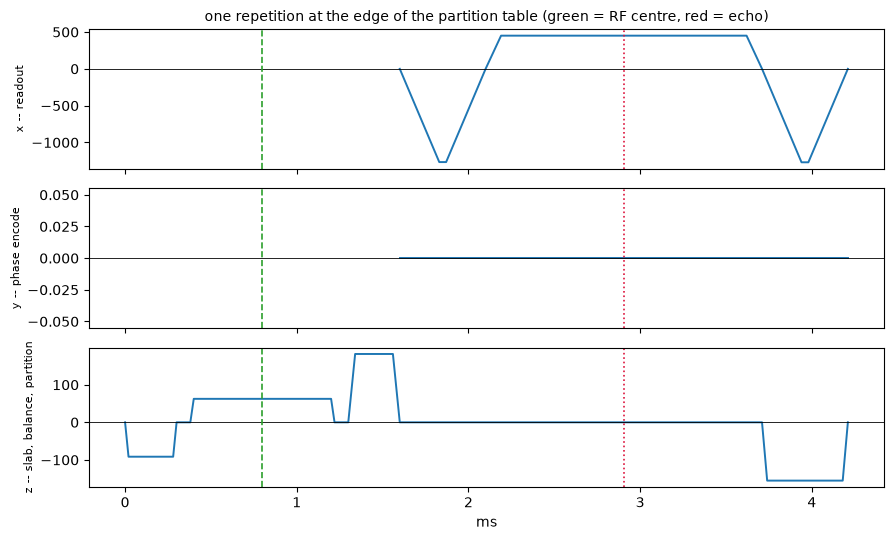

In [8]:
import matplotlib.pyplot as plt

one = sc.compile(tr.build(line=tr.center_line, partition=NZ - 1), opts)
fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
for row, (axis, name) in enumerate(zip(range(3), ('x -- readout', 'y -- phase encode',
                                                  'z -- slab, balance, partition'))):
    times, amps = one.waveforms_and_times()[0][axis]
    axes[row].plot(np.asarray(times) * 1e3, np.asarray(amps) / 1e3, lw=1.4)
    axes[row].axhline(0.0, color='k', lw=0.6)
    axes[row].axvline(tr.time_to_echo() * 1e3, color='crimson', ls=':', lw=1.2)
    axes[row].axvline(tr.time_to_rf_center() * 1e3, color='tab:green', ls='--', lw=1.2)
    axes[row].set_ylabel(name, fontsize=8)
axes[0].set_title('one repetition at the edge of the partition table '
                  '(green = RF centre, red = echo)', fontsize=10)
axes[-1].set_xlabel('ms')
fig.tight_layout()

### What the symmetric realisation buys

At `kz = 0` the z axis carries nothing but slab-selection balancing, and because the two lobes are
equal and equally spaced about the echo, the **first** moment over the interval vanishes too — the
limit a symmetric bSSFP scheme is described by. Away from the centre the partition encoding adds
its own first-moment term, of opposite sign at the two edges of the table.

This is the same thing the phase encoding already does on `y`, and it is not a defect introduced by
going to 3D: an encode and its rewind sit on opposite sides of the echo, so their first moments add
rather than cancel.

In [9]:
def m1z_about_echo(partition):
    '''First moment on z over one RF-to-RF interval, referenced to the echo.'''
    local = train([(tr.center_line, partition),
                   (0, (partition + 5) % NZ), (NY - 1, (partition + 9) % NZ)])
    c = rf_centres(local)
    times, amps = local.waveforms_and_times()[0][2]
    t, g = np.asarray(times, float), np.asarray(amps, float)
    echo_t = c[0] + tr.te_s
    grid = np.unique(np.concatenate([t[(t > c[0]) & (t < c[1])], [c[0], c[1]]]))
    y = np.interp(grid, t, g, left=0.0, right=0.0) * (grid - echo_t)
    return float(np.trapezoid(y, grid))


for p in (0, tr.center_partition, NZ - 1):
    print(f'partition {p:>2}  K = {tr.pe_z.k_per_m(p):+7.2f} 1/m   '
          f'M1z = {m1z_about_echo(p):+10.3e} s/m')

partition  0  K =  -83.33 1/m   M1z = +2.092e-01 s/m
partition  8  K =   +0.00 1/m   M1z = +3.469e-17 s/m


partition 15  K =  +72.92 1/m   M1z = -1.830e-01 s/m

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/1340061804.py:34: SeqCraftWarning: 9 blocks over the vector-norm limit (legal on real amplifiers): bssfp_3d, bssfp_3d.PhaseEncode (slew 129% at 3.710 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (grad 120% at 5.810 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (slew 140% at 5.810 ms), bssfp_3d, bssfp_3d.PhaseEncode (grad 120% at 7.920 ms), bssfp_3d, bssfp_3d.PhaseEncode (slew 152% at 7.920 ms) (+4 more sites)
  return sc.compile(tree, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/1340061804.py:34: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (grad 120% at 5.810 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (slew 140% at 5.810 ms), bssfp_3d, bssfp_3d.PhaseEncode (grad 120% at 7.920 ms), bssfp_3d, bssfp_3d.PhaseEncode (slew 171% at 7.920 ms), bssfp_3d.CartesianLine, bssfp_3d.PhaseEncode (grad 119% at 10.020

## Selective and non-selective are two excitation modes

`slab_thickness_mm=None` does not mean "the same design with the selection gradient removed". The
two modes have different RF families:

```text
slab-selective imaging default    shaped RF   + selection gradient
non-selective imaging default     hard RF     + no selection gradient
```

Those are two different physical excitations, and picking the right RF family is part of choosing
the mode rather than a consequence of it. The same rule is shared with `sc.modules.GRE3DTR`, so the
two 3D kernels cannot answer it differently.

A shaped but spatially non-selective pulse -- a spectrally selective excitation, for instance -- is
a third, deliberate design, and `rf_pulse` still asks for it. It is not what either default means.

In [10]:
def excitation_shape(module):
    events = [ev for _, ev, _ in sc.flatten(module.exc(phase_deg=0.0))]
    rf = next(ev for ev in events if getattr(ev, 'type', None) == 'rf')
    channels = {ev.channel for ev in events if getattr(ev, 'type', None) in {'grad', 'trap'}}
    return np.asarray(rf.signal).size, float(pp.calc_duration(rf)), channels or {'none'}


common = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, flip_deg=FLIP_DEG,
              bandwidth_hz_px=BANDWIDTH_HZ_PX)
for label, module in (
    ('slab-selective', sc.modules.bSSFP3DTR(**common, slab_thickness_mm=SLAB_MM)),
    ('non-selective', sc.modules.bSSFP3DTR(**common, slab_thickness_mm=None)),
):
    n, duration, channels = excitation_shape(module)
    print(f'{label:<16} {n:>5} RF samples  {duration * 1e3:6.3f} ms  '
          f'gradient on {"/".join(sorted(channels))}')

slab-selective    3000 RF samples   3.130 ms  gradient on z
non-selective        2 RF samples   0.330 ms  gradient on none


## Preparation: a linear flip-angle ramp

Starting a bSSFP train from equilibrium produces a large transient. Hargreaves et al. (2001) set
the terms precisely: the magnetisation obeys `M(k+1) = A M(k) + B`, so the error against the steady
state decays as the eigenvalues of `A`. Those eigenvalues are a property of T1, T2, TR, the flip
angle and off-resonance — **a preparation cannot change them.** What a preparation changes is the
*initial* error, and therefore the amplitude of what the first imaging repetitions see.

The named schemes are the `alpha/2 - TR/2` pulse and linearly ramped flip angles (Le Roux 2003;
Hargreaves et al. 2001). The literature does not rank them, so
[`02`](02_simulate_and_reconstruct.ipynb) measures both on this protocol, across the off-resonance
band rather than only on resonance:

```text
peak transient over the first 60 imaging repetitions, as a fraction of the late-train signal
white matter, band edge (null) at 119 Hz

                        0 Hz    59 Hz    89 Hz   107 Hz
no preparation          3.59     5.31    10.41    25.24
alpha/2 - TR/2          1.53     3.59     9.55    24.71
24-step flip ramp       1.45     2.55     5.82    10.80
```

**On resonance the two are equivalent; across the band they are not.** The `alpha/2` pulse is
non-selective, so it rotates magnetisation toward the steady state for part of the off-resonance
range and away from it for the rest — which is the behaviour Hargreaves describes, and the reason
it loses to the ramp as the band edge approaches. Both are equally insensitive to B1 error over
`+-10%`, so that does not separate them either.

So this example ships the **ramp**. Its length was chosen the same way: lengthening it improves the
band-edge transient with clearly diminishing returns, and 24 steps is where that knee falls on this
protocol. The 2D example beside this one ships a 20-step ramp at its own TR.

In [11]:
RAMP_STEPS = 24                 # chosen in 02 by measuring 8 / 16 / 24 / 32
PHASE_STEP = 180.0              # the 0/pi phase cycle


def ramp_kernels(kernel, steps=RAMP_STEPS):
    '''`steps` repetitions rising linearly to the imaging flip angle, at the imaging TR.'''
    return [
        sc.modules.bSSFP3DTR(
            opts=opts, fov_mm=kernel.fov_mm, matrix=kernel.matrix,
            slab_thickness_mm=SLAB_MM, flip_deg=FLIP_DEG * (k + 1) / (steps + 1),
            bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S, tr_s=kernel.tr_s,
        )
        for k in range(steps)
    ]


print(f'{RAMP_STEPS} ramp repetitions = {RAMP_STEPS * tr.tr_s * 1e3:.0f} ms, '
      f'flip rising {FLIP_DEG / (RAMP_STEPS + 1):.1f} -> '
      f'{FLIP_DEG * RAMP_STEPS / (RAMP_STEPS + 1):.1f} degrees')

24 ramp repetitions = 101 ms, flip rising 1.8 -> 43.2 degrees


## View ordering, and why it is not free

Segmented SSFP acquisition has **two** ordering constraints, and they compete (Spincemaille et al.
2004). The central views must be collected when the magnetisation is where the protocol wants it,
and the trajectory through `(ky, kz)` must be **smooth**, because repetition-to-repetition changes
in the phase-encode gradients drive eddy currents and bSSFP is unusually sensitive to them.

The ordering here is the **loop order**: lines of constant `kz` acquired in turn, with `ky` swept
**bidirectionally** so that consecutive partitions reverse direction. That is the standard smooth
variant -- at a partition boundary `ky` stays at the edge it just reached and only `kz` steps, so
no repetition ever jumps across the table. The fan and loop schemes in that paper refine this
further by rotating each line's starting point so the central views land at a chosen moment, which
matters when an inversion or saturation sets the contrast; this acquisition has no such preparation
to time against, so it keeps the simpler form.

Note what the sweep does to the kernel's contract: **almost every repetition changes `ky`, and
every partition boundary changes `kz`**. A repetition whose balance depended on its successor's
partition could not be ordered this way at all.

In [12]:
SEGMENTS = 4
RECOVERY_S = 1.0                # between segments; a protocol sets this from what it waits for


def view_order(ny, nz):
    '''Loop order: constant-kz lines in turn, ky swept bidirectionally.'''
    out = []
    for partition in range(nz):
        lines = range(ny) if partition % 2 == 0 else reversed(range(ny))
        out.extend((line, partition) for line in lines)
    return out


def prepared_run(kernel, views, start_index=0):
    '''A ramp followed by `views`, returned as (blocks, duration).  The caller places it.'''
    tree, at, n = sc.LogicBlock('run'), 0.0, start_index
    for rep in ramp_kernels(kernel):
        tree.add(at, rep(line=kernel.center_line, partition=kernel.center_partition,
                         phase_deg=PHASE_STEP * n, acquire=False))
        at, n = at + rep.tr_s, n + 1
    for line, partition in views:
        tree.add(at, kernel(line=line, partition=partition, phase_deg=PHASE_STEP * n))
        at, n = at + kernel.tr_s, n + 1
    return tree, at


def continuous(kernel):
    '''One ramp, then the whole table.'''
    views = view_order(kernel.matrix[1], kernel.matrix[2])
    tree, _ = prepared_run(kernel, views)
    return tree, views


def segmented(kernel):
    '''One ramp per segment of partitions, with a recovery interval between segments.'''
    ny, nz = kernel.matrix[1], kernel.matrix[2]
    views = view_order(ny, nz)
    per_segment = len(views) // SEGMENTS
    tree, at = sc.LogicBlock('segmented'), 0.0
    for s in range(SEGMENTS):
        run, used = prepared_run(kernel, views[s * per_segment:(s + 1) * per_segment])
        tree.add(at, run)
        at += used + RECOVERY_S
    return tree, views


steps = [abs(view_order(NY, NZ)[i + 1][0] - view_order(NY, NZ)[i][0])
         for i in range(len(view_order(NY, NZ)) - 1)]
print(f'loop order over {NY} x {NZ}: largest |ky| step between neighbours is {max(steps)} '
      f'(a partition-major sweep that restarts each line would step {NY - 1})')

loop order over 192 x 16: largest |ky| step between neighbours is 1 (a partition-major sweep that restarts each line would step 191)


## Two protocols, written from the same policy

The acquisition above is the one a user would plausibly run: 3072 repetitions, about 13 seconds.
Simulating it is another matter -- balanced SSFP keeps its coherence pathways alive, so the cost of
an MRzero simulation is voxels x repetitions x states and all three are large for this family.

So this notebook also writes a **reduced validation acquisition**: the same preparation, the same
phase cycle, the same loop ordering, the same segmentation rule, and -- importantly -- **the same
TR**, pinned explicitly so the magnetisation sees an identical train. Only the encoding is smaller.
That is the file [`02`](02_simulate_and_reconstruct.ipynb) simulates, and it is written here from
the same functions rather than rebuilt there, so the relationship between the two is visible.

In [13]:
tr_validation = sc.modules.bSSFP3DTR(
    opts=opts, fov_mm=FOV_MM, matrix=(48, 32, 8), slab_thickness_mm=SLAB_MM,
    flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
    tr_s=tr.tr_s,                       # the representative TR, so the train is the same train
)
assert abs(tr_validation.tr_s - tr.tr_s) < 1e-12

PROTOCOLS = {'bssfp_3d': tr, 'bssfp_3d_validation': tr_validation}
print(f'{"protocol":24s}{"matrix":>16s}{"TE ms":>9s}{"TR ms":>9s}{"views":>8s}{"scan s":>9s}')
for name, kernel in PROTOCOLS.items():
    n = kernel.matrix[1] * kernel.matrix[2]
    print(f'{name:24s}{str(kernel.matrix):>16s}{kernel.te_s * 1e3:9.3f}{kernel.tr_s * 1e3:9.3f}'
          f'{n:8d}{n * kernel.tr_s:9.2f}')

protocol                          matrix    TE ms    TR ms   views   scan s
bssfp_3d                  (192, 192, 16)    2.104    4.210    3072    12.93
bssfp_3d_validation          (48, 32, 8)    2.100    4.210     256     1.08


In [14]:
TABLES, definitions_of = {}, {}
for name, kernel in PROTOCOLS.items():
    ny, nz = kernel.matrix[1], kernel.matrix[2]
    definitions = {
        'FOV': [FOV_MM[0] * 1e-3, FOV_MM[1] * 1e-3, FOV_MM[2] * 1e-3],
        'Matrix': list(kernel.matrix),
        'TE': kernel.te_s, 'TR': kernel.tr_s,
        'SlabThickness': SLAB_MM * 1e-3, 'FlipAngle': FLIP_DEG,
    }
    for suffix, build in (('', continuous), ('_segmented', segmented)):
        tree, views = build(kernel)
        seq = sc.compile(tree, opts, name=f'{name}{suffix}', definitions=definitions)
        seq.write(str(SEQ_DIR / f'{name}{suffix}.seq'))
        TABLES[f'{name}{suffix}'] = views
        print(f'{name}{suffix:<11s} {len(views):5d} views, {seq.duration()[0]:7.2f} s')
    definitions_of[name] = definitions

centre_at = TABLES['bssfp_3d'].index((tr.center_line, tr.center_partition))
per_segment = len(TABLES['bssfp_3d']) // SEGMENTS
print()
print(f'centre of k-space: view {centre_at} of {len(TABLES["bssfp_3d"])}, '
      f'{centre_at % per_segment} views into segment {centre_at // per_segment} '
      f'(each segment is {per_segment} views after its own ramp)')

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/3069981586.py:12: SeqCraftWarning: 9045 blocks over the vector-norm limit (legal on real amplifiers): run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (grad 120% at 102.640 ms), run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (slew 140% at 102.640 ms), run.bSSFP3DTR, run.bSSFP3DTR.PhaseEncode (grad 121% at 104.750 ms), run.bSSFP3DTR, run.bSSFP3DTR.PhaseEncode (slew 162% at 104.750 ms), run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (grad 119% at 106.850 ms) (+9040 more sites)
  seq = sc.compile(tree, opts, name=f'{name}{suffix}', definitions=definitions)


bssfp_3d             3072 views,   13.03 s


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/3069981586.py:12: SeqCraftWarning: 9045 blocks over the vector-norm limit (legal on real amplifiers): segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (grad 120% at 102.640 ms), segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (slew 140% at 102.640 ms), segmented.run.bSSFP3DTR, segmented.run.bSSFP3DTR.PhaseEncode (grad 121% at 104.750 ms), segmented.run.bSSFP3DTR, segmented.run.bSSFP3DTR.PhaseEncode (slew 162% at 104.750 ms), segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (grad 119% at 106.850 ms) (+9040 more sites)
  seq = sc.compile(tree, opts, name=f'{name}{suffix}', definitions=definitions)


bssfp_3d_segmented   3072 views,   16.34 s


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/3069981586.py:12: SeqCraftWarning: 445 blocks over the vector-norm limit (legal on real amplifiers): run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (slew 135% at 102.860 ms), run.bSSFP3DTR, run.bSSFP3DTR.PhaseEncode (slew 158% at 104.620 ms), run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (slew 131% at 107.070 ms), run.bSSFP3DTR, run.bSSFP3DTR.PhaseEncode (slew 155% at 108.830 ms), run.bSSFP3DTR.CartesianLine, run.bSSFP3DTR.PhaseEncode (slew 127% at 111.280 ms) (+440 more sites)
  seq = sc.compile(tree, opts, name=f'{name}{suffix}', definitions=definitions)


bssfp_3d_validation              256 views,    1.18 s


bssfp_3d_validation_segmented    256 views,    4.48 s

centre of k-space: view 1632 of 3072, 96 views into segment 2 (each segment is 768 views after its own ramp)


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_74897/3069981586.py:12: SeqCraftWarning: 445 blocks over the vector-norm limit (legal on real amplifiers): segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (slew 135% at 102.860 ms), segmented.run.bSSFP3DTR, segmented.run.bSSFP3DTR.PhaseEncode (slew 158% at 104.620 ms), segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (slew 131% at 107.070 ms), segmented.run.bSSFP3DTR, segmented.run.bSSFP3DTR.PhaseEncode (slew 155% at 108.830 ms), segmented.run.bSSFP3DTR.CartesianLine, segmented.run.bSSFP3DTR.PhaseEncode (slew 127% at 111.280 ms) (+440 more sites)
  seq = sc.compile(tree, opts, name=f'{name}{suffix}', definitions=definitions)


In [15]:
np.savez(
    SEQ_DIR / 'bssfp_3d_nominal.npz',
    fov_mm=np.array(FOV_MM), slab_mm=SLAB_MM, flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
    phase_step=PHASE_STEP, preparation='linear flip-angle ramp', ramp_steps=RAMP_STEPS,
    segments=SEGMENTS, recovery_s=RECOVERY_S, view_order='loop order, bidirectional ky',
    matrix=np.array(MATRIX), te_s=tr.te_s, tr_s=tr.tr_s,
    center_line=tr.center_line, center_partition=tr.center_partition,
    table=np.array(TABLES['bssfp_3d']),
    validation_matrix=np.array(tr_validation.matrix),
    validation_te_s=tr_validation.te_s, validation_tr_s=tr_validation.tr_s,
    validation_center_line=tr_validation.center_line,
    validation_center_partition=tr_validation.center_partition,
    validation_table=np.array(TABLES['bssfp_3d_validation']),
)
print('wrote four .seq files and the nominal metadata 02 reads')

wrote four .seq files and the nominal metadata 02 reads


## The artifact contract

`02` consumes these files, so what they contain is an interface rather than an implementation
detail. These checks re-read what was just written and assert the properties `02` depends on --
they run every time this notebook does, which includes continuous integration.

In [16]:
nominal = np.load(SEQ_DIR / 'bssfp_3d_nominal.npz')
for name, kernel in PROTOCOLS.items():
    prefix = '' if name == 'bssfp_3d' else 'validation_'
    table = [tuple(int(v) for v in row) for row in nominal[f'{prefix}table']]
    assert table == TABLES[name], f'{name}: the recorded table is not the one acquired'
    assert abs(float(nominal[f'{prefix}te_s']) - kernel.te_s) < 1e-12
    assert abs(float(nominal[f'{prefix}tr_s']) - kernel.tr_s) < 1e-12

    for suffix in ('', '_segmented'):
        path = SEQ_DIR / f'{name}{suffix}.seq'
        assert path.exists(), f'{path} was not written'
        seq = pp.Sequence()
        seq.read(str(path))
        addresses, adcs = [], 0
        for i in range(1, len(seq.block_events) + 1):
            block = seq.get_block(i)
            if getattr(block, 'adc', None) is not None:
                adcs += 1
            label = getattr(block, 'label', None)
            if label is not None:
                got = {lab.label: int(lab.value) for lab in np.atleast_1d(label)}
                if 'LIN' in got and 'PAR' in got:
                    addresses.append((got['LIN'], got['PAR']))
        assert adcs == len(TABLES[name]), f'{path}: {adcs} readouts for {len(TABLES[name])} views'
        assert len(set(addresses)) == len(addresses), f'{path}: a k-space address repeats'
        assert addresses == TABLES[name], f'{path}: does not walk the recorded table'
        assert abs(float(seq.definitions['TR']) - kernel.tr_s) < 1e-9
        assert abs(float(seq.definitions['TE']) - kernel.te_s) < 1e-9
        print(f'{path.name:34s} {adcs:5d} readouts, all addresses distinct, TE/TR match')

for field in ('preparation', 'ramp_steps', 'segments', 'recovery_s', 'view_order', 'phase_step'):
    assert field in nominal, f'02 needs {field} in the nominal metadata'
print()
print('both acquisitions of both protocols walk their recorded tables; '
      'the policy fields 02 reads are present')

bssfp_3d.seq                        3072 readouts, all addresses distinct, TE/TR match


bssfp_3d_segmented.seq              3072 readouts, all addresses distinct, TE/TR match
bssfp_3d_validation.seq              256 readouts, all addresses distinct, TE/TR match
bssfp_3d_validation_segmented.seq    256 readouts, all addresses distinct, TE/TR match

both acquisitions of both protocols walk their recorded tables; the policy fields 02 reads are present


## The refusals

A request the design cannot reach is refused with the number that *is* reachable, rather than
silently rounded.

In [17]:
for field, value in (('te_s', tr.min_te_s * 0.5),
                     ('tr_s', tr.min_tr_s * 0.5)):
    try:
        sc.modules.bSSFP3DTR(**common, slab_thickness_mm=SLAB_MM, **{field: value})
    except sc.ConfigurationError as error:
        print(f'{field}: {str(error).splitlines()[0]}')

try:
    tr.build(line=0, partition=NZ)
except sc.ConfigurationError as error:
    print(f'partition: {str(error).splitlines()[0]}')

try:
    sc.modules.bSSFP3DTR(**common, slab_thickness_mm=None, rf_time_bw_product=4.0)
except sc.ConfigurationError as error:
    print(f'rf_time_bw_product: {str(error).splitlines()[0]}')

te_s: te_s = 0.867 ms is shorter than this repetition can achieve.
tr_s: tr_s = 2.105 ms is shorter than a symmetric repetition can achieve.
partition: partition 16 is outside the table this repetition encodes.
rf_time_bw_product: a time-bandwidth product needs a shaped pulse, and this excitation is a hard block pulse.


## Limitations

**This builds a balanced waveform; it does not establish a steady state.** The two are different
claims. Zero net area per repetition is a property of the gradients and is checked above. Whether
the magnetisation has reached the bSSFP steady state depends on T1, T2, the flip angle and how many
repetitions have run. The `alpha/2 - TR/2` preparation reduces the amplitude of the opening
transient; it does not make the train converge sooner, and
[`02`](02_simulate_and_reconstruct.ipynb) measures both of those separately.

**Nothing here is an image.** The `.seq` files and the k-space trace are what this notebook
produces. Whether the acquisitions reconstruct into the right volume, what interrupted segmentation
does to it, and whether the off-resonance response looks like bSSFP at all are questions a waveform
check cannot answer -- they are `02`'s subject.

**The partition encoding carries a first moment away from `kz = 0`**, measured above. For
stationary tissue that is irrelevant; for flow along the slab axis it is not, and this module does
not offer flow compensation on `z`.

**The protocol is sized for its own validation.** `48 x 32 x 8` is a real 3D acquisition but a
small one, chosen so `02` can simulate these exact files in minutes rather than hours. A scanner
protocol would be larger, and nothing here changes with the matrix except the cost.

## Summary

- `bSSFP3DTR` is one balanced repetition: net gradient area zero on every axis over the
  RF-centre-to-RF-centre interval, with `TE = TR/2` as the default realisation and not the
  definition.
- In 3D the `z` axis selects the slab, balances that selection, and encodes `kz`. The encode is
  lumped into the balancing lobe because the axis is already occupied in that window.
- **Each repetition discharges its own partition encoding**, so balance never depends on what the
  next repetition acquires — which is what lets the caller choose the view order. Measured across
  partition jumps spanning the whole table.
- One selection-side window serves every partition, which keeps TE and TR independent of `kz`.
  Both lobes take it, which gives the symmetric realisation whose first moment vanishes at
  `kz = 0`.
- Selective and non-selective are two excitation modes with different RF families, not one mode
  with a gradient switched off.
- Preparation is a **24-step linear flip-angle ramp**, chosen by measuring candidates across the
  off-resonance band rather than only on resonance. `alpha/2 - TR/2` ties it at the passband
  centre and loses toward the band edge, because a non-selective half-angle pulse rotates part of
  the frequency range the wrong way.
- A preparation changes the transient's **amplitude**, not the rate it decays at. That rate is an
  eigenvalue of the repetition's own transfer matrix, set by T1, T2, TR, flip angle and
  off-resonance.
- The view order is the **loop order with a bidirectional `ky` sweep**, so no repetition jumps
  across the table -- the smoothness criterion segmented SSFP needs for eddy currents.
- The phase progression, preparation, segmentation and view order are all the caller's.
- Two protocols are written from the same policy code: the representative acquisition, and a
  reduced one at the **same TR** that `02` can afford to simulate.

## References

- Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.*
  J Magn Reson Imaging 2013;38:2-11.
- Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004.
  Section 14.1, "Balanced SSFP (True FISP)".
- Scheffler K, Lehnhardt S. *Principles and applications of balanced SSFP techniques.*
  Eur Radiol 2003;13:2409-2418.